# **1. Objective**

The objective of this notebook is to generate a 90-day temperature forecast
for **winter 2026–2027** using the selected final model.

The forecast is produced using a recursive multi-step strategy:

1. The model is trained on all available historical data (2021–2026).
2. Predictions are generated sequentially.
3. Each predicted value is fed back as input for subsequent steps.

Forecast horizon: 90 days.


# **2. Imports and Configuration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
})

# **3. Load and Prepare Full Dataset**

The full cleaned dataset is loaded.
Lag and rolling features are reconstructed exactly as in previous notebooks.

In [2]:
df = pd.read_csv("../data/processed/winter_2021_2026.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

df_model = df.copy()
df_model["tavg"] = pd.to_numeric(df_model["tavg"], errors="coerce")

# Create lag features
for lag in range(1, 8):
    df_model[f"lag_{lag}"] = df_model["tavg"].shift(lag)

# Rolling statistics (shifted)
df_model["rolling_mean_3"] = df_model["tavg"].rolling(3).mean().shift(1)
df_model["rolling_mean_7"] = df_model["tavg"].rolling(7).mean().shift(1)
df_model["rolling_std_7"] = df_model["tavg"].rolling(7).std().shift(1)

features = [col for col in df_model.columns
            if col.startswith("lag_") or col.startswith("rolling")]

df_model = df_model[["tavg"] + features].dropna().copy()

# **4. Train Final Model on Full Data**
The selected final model (Linear Regression) is trained
using all available historical observations.

In [3]:
X_full = df_model[features]
y_full = df_model["tavg"]

model = LinearRegression()
model.fit(X_full, y_full)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# **5. Recursive 90-Day Forecast**
Forecasts are generated sequentially.

For each future step:
1. Lag values are constructed from the most recent available observations.
2. Rolling statistics are computed.
3. The model predicts the next temperature value.
4. The prediction is appended to the history.

In [4]:
forecast_horizon = 90

history = df_model.copy()
future_predictions = []

for step in range(forecast_horizon):
    
    last_row = history.iloc[-1]
    
    # Construct feature vector manually
    lag_values = history["tavg"].iloc[-7:].values[::-1]
    
    feature_dict = {}
    
    for i in range(1, 8):
        feature_dict[f"lag_{i}"] = lag_values[i-1]
    
    feature_dict["rolling_mean_3"] = history["tavg"].iloc[-3:].mean()
    feature_dict["rolling_mean_7"] = history["tavg"].iloc[-7:].mean()
    feature_dict["rolling_std_7"] = history["tavg"].iloc[-7:].std()
    
    X_next = pd.DataFrame([feature_dict])
    
    y_next = model.predict(X_next)[0]
    
    # Append prediction
    next_date = history.index[-1] + pd.Timedelta(days=1)
    
    new_row = pd.DataFrame(
        {"tavg": y_next},
        index=[next_date]
    )
    
    history = pd.concat([history, new_row])
    future_predictions.append(y_next)

# **6. Create Forecast Index**

In [5]:
last_date = df_model.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_horizon,
    freq="D"
)

forecast_series = pd.Series(
    future_predictions,
    index=future_dates
)

# **7. Forecast Visualization**

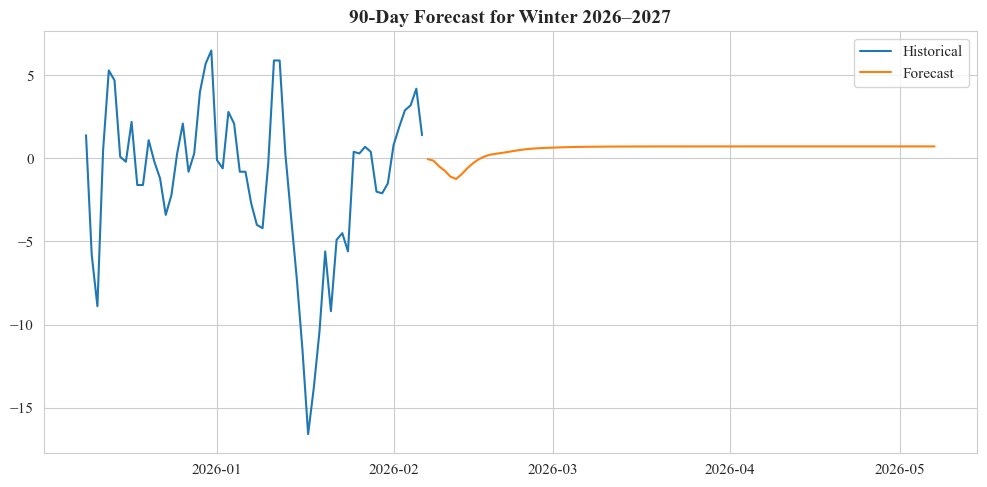

In [6]:
plt.figure(figsize=(10,5))

# Plot last 60 historical days
plt.plot(df_model.index[-60:], 
         df_model["tavg"].iloc[-60:], 
         label="Historical")

# Plot forecast
plt.plot(forecast_series.index, 
         forecast_series.values, 
         label="Forecast")

plt.title("90-Day Forecast for Winter 2026–2027")
plt.legend()
plt.tight_layout()
plt.show()

# **8. Interpretation**

Key observations:

1. Forecast values gradually stabilize over time.
2. Recursive forecasting accumulates uncertainty.
3. Long-horizon predictions tend to revert toward the learned mean structure.

This behavior reflects the autoregressive nature of the model.

# **9. Limitations**
1. Recursive forecasting accumulates error over time.
2. Only lag-based temperature features are used.
3. No external meteorological predictors are included.
4. Forecast uncertainty is not explicitly modeled.

# **10. Final Project Completion**

The project now includes:

1. Exploratory data analysis
2. Feature engineering justification
3. Baseline and advanced model comparison
4. Model diagnostics
5. Out-of-sample 90-day forecast

This completes the full forecasting pipeline.       